# Datos Aeronet: GasLab_SJ_CostaRica 

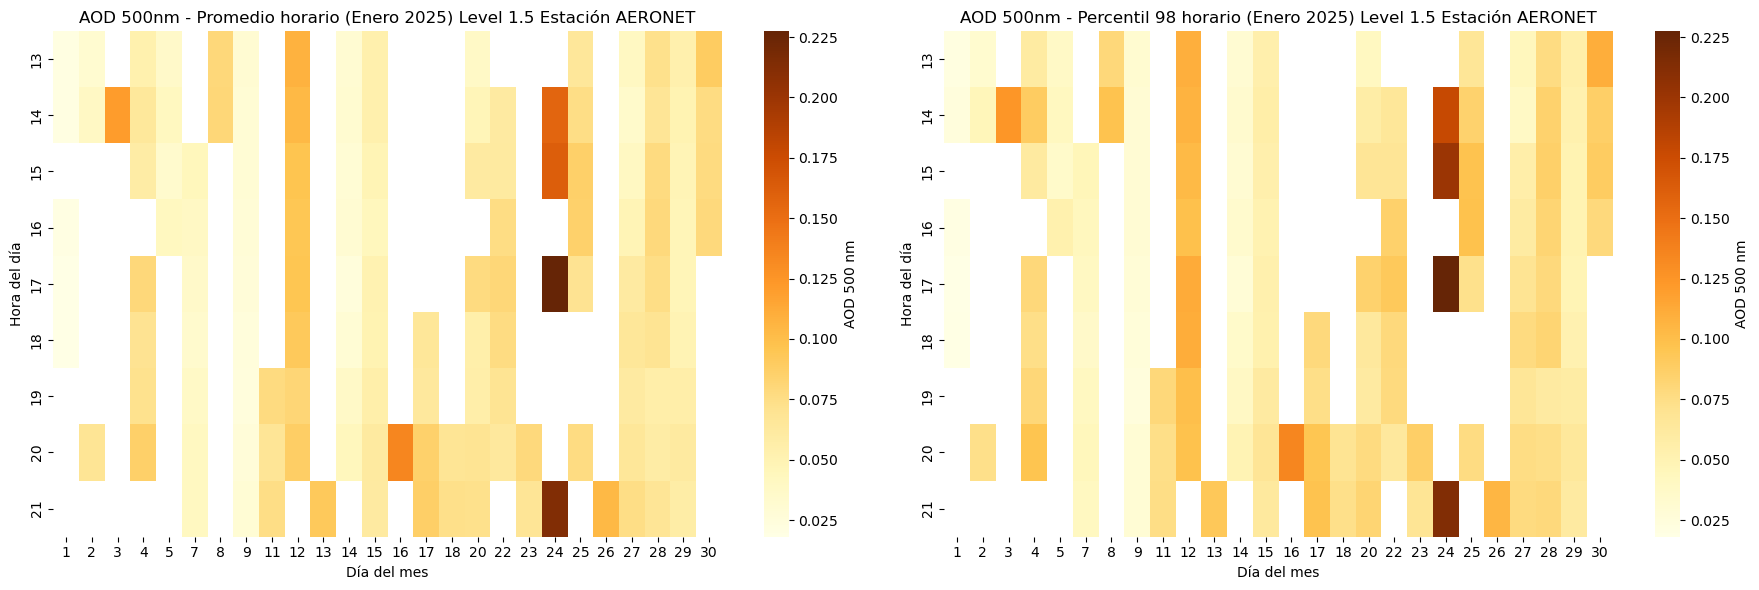

[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/AERONET/aeronet_202501_refstyle_L1_5.png


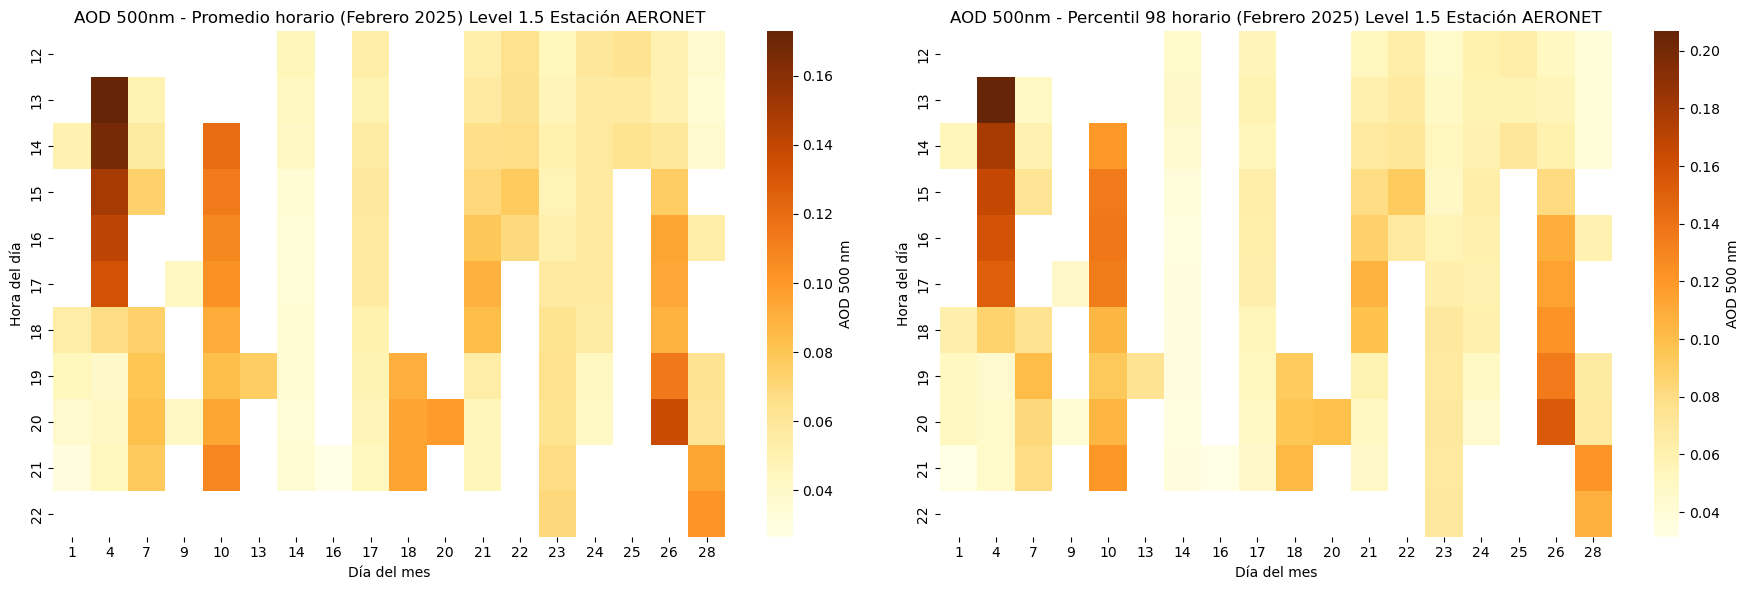

[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/AERONET/aeronet_202502_refstyle_L1_5.png


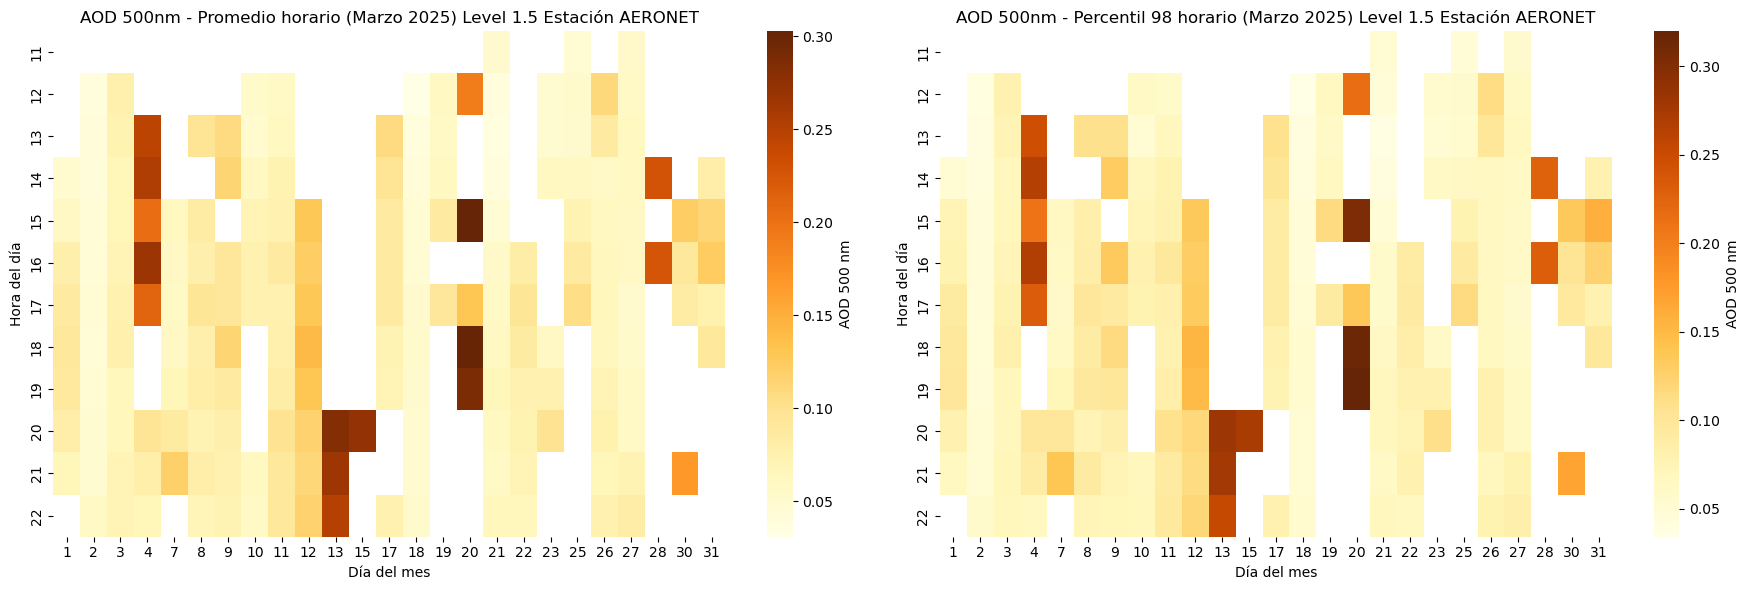

[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/AERONET/aeronet_202503_refstyle_L1_5.png


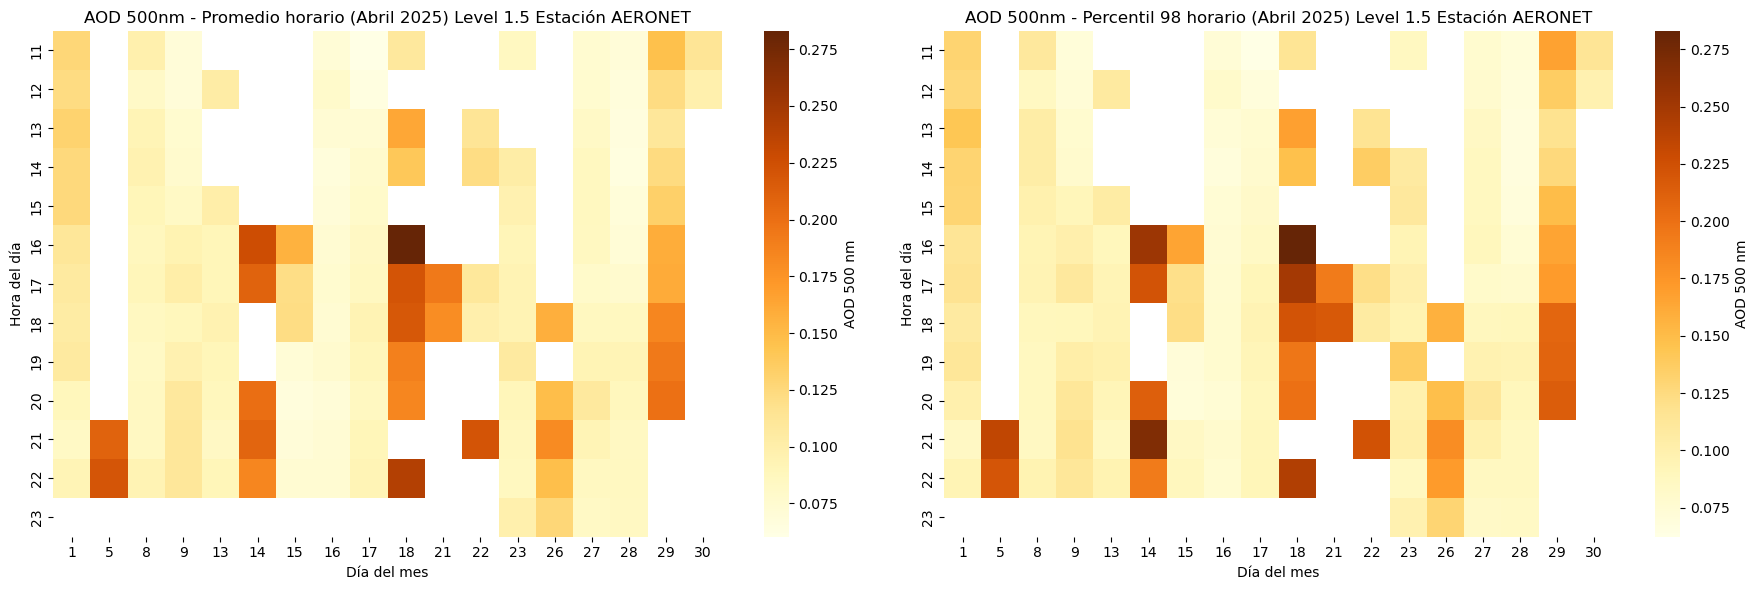

[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/AERONET/aeronet_202504_refstyle_L1_5.png


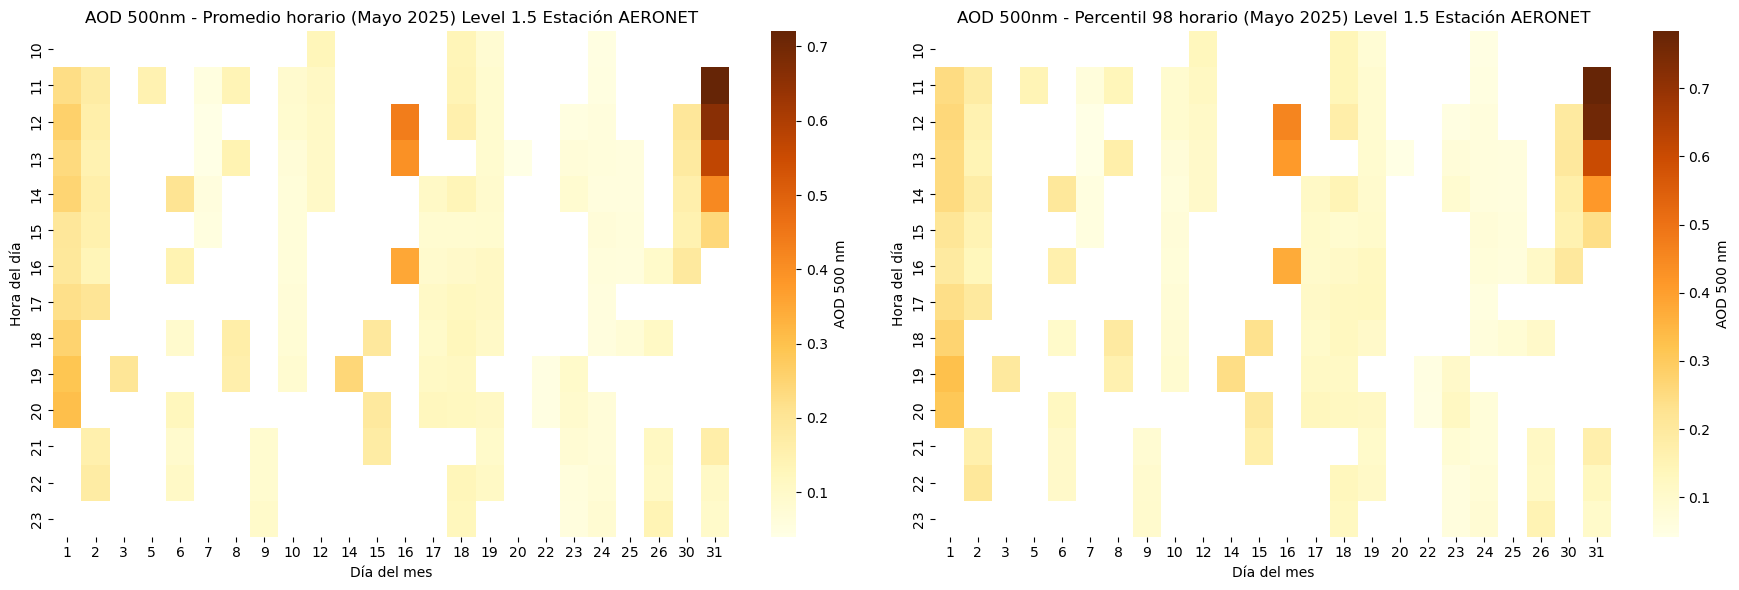

[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/AERONET/aeronet_202505_refstyle_L1_5.png


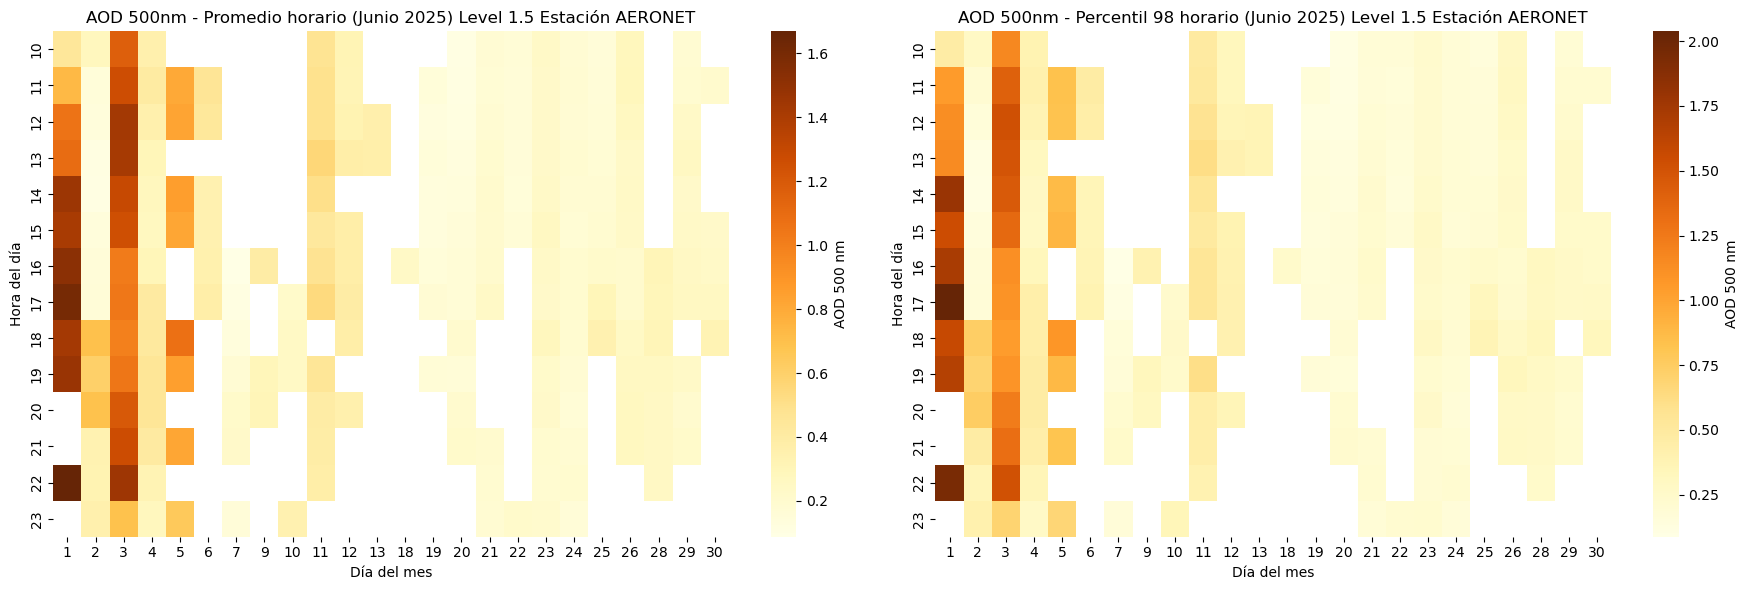

[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/AERONET/aeronet_202506_refstyle_L1_5.png


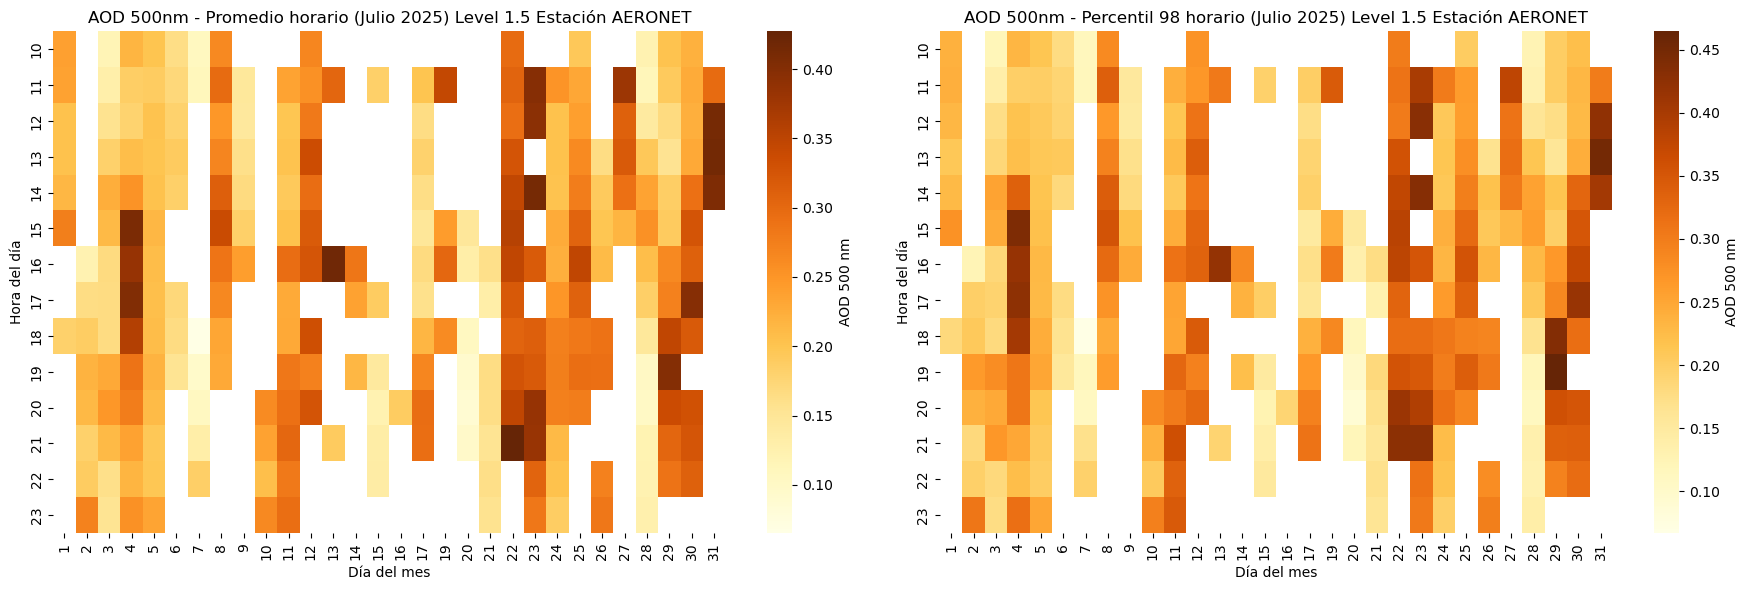

[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/AERONET/aeronet_202507_refstyle_L1_5.png


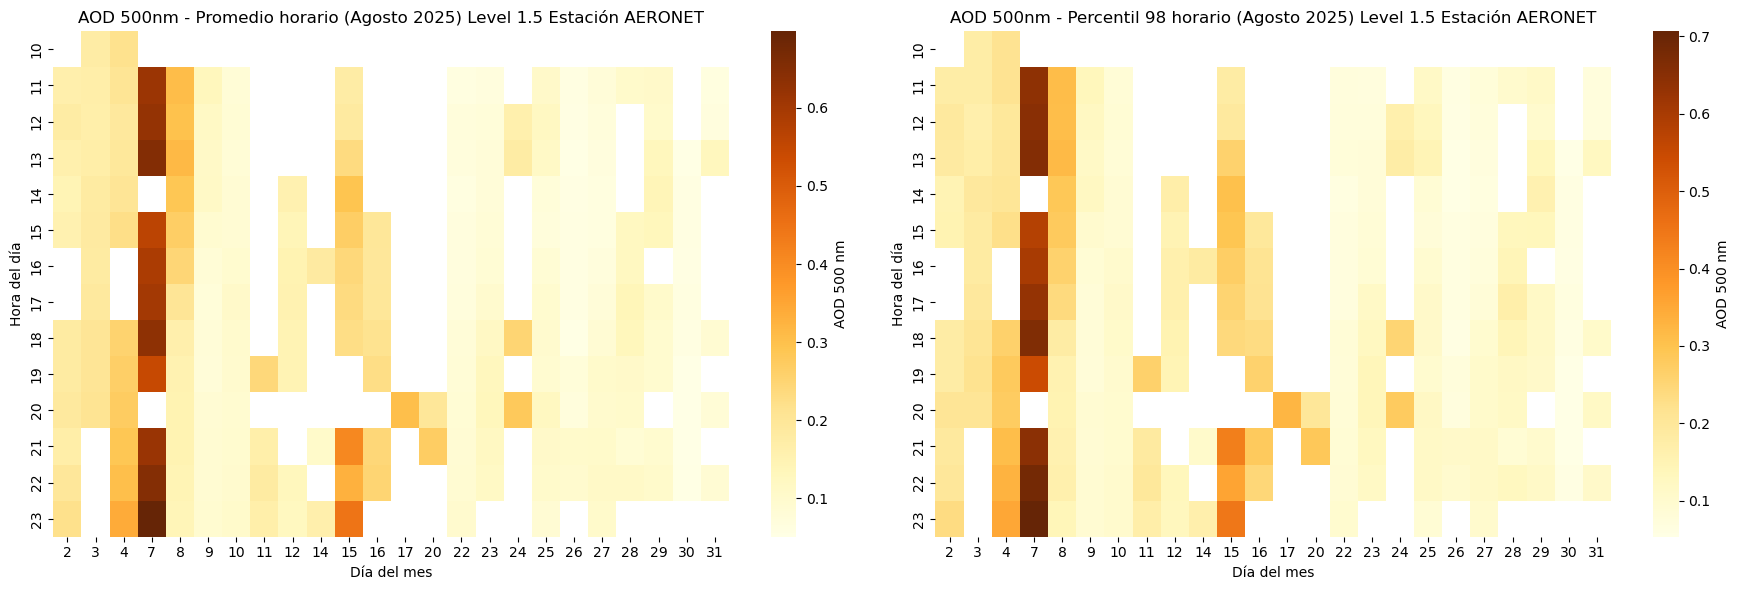

[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/AERONET/aeronet_202508_refstyle_L1_5.png


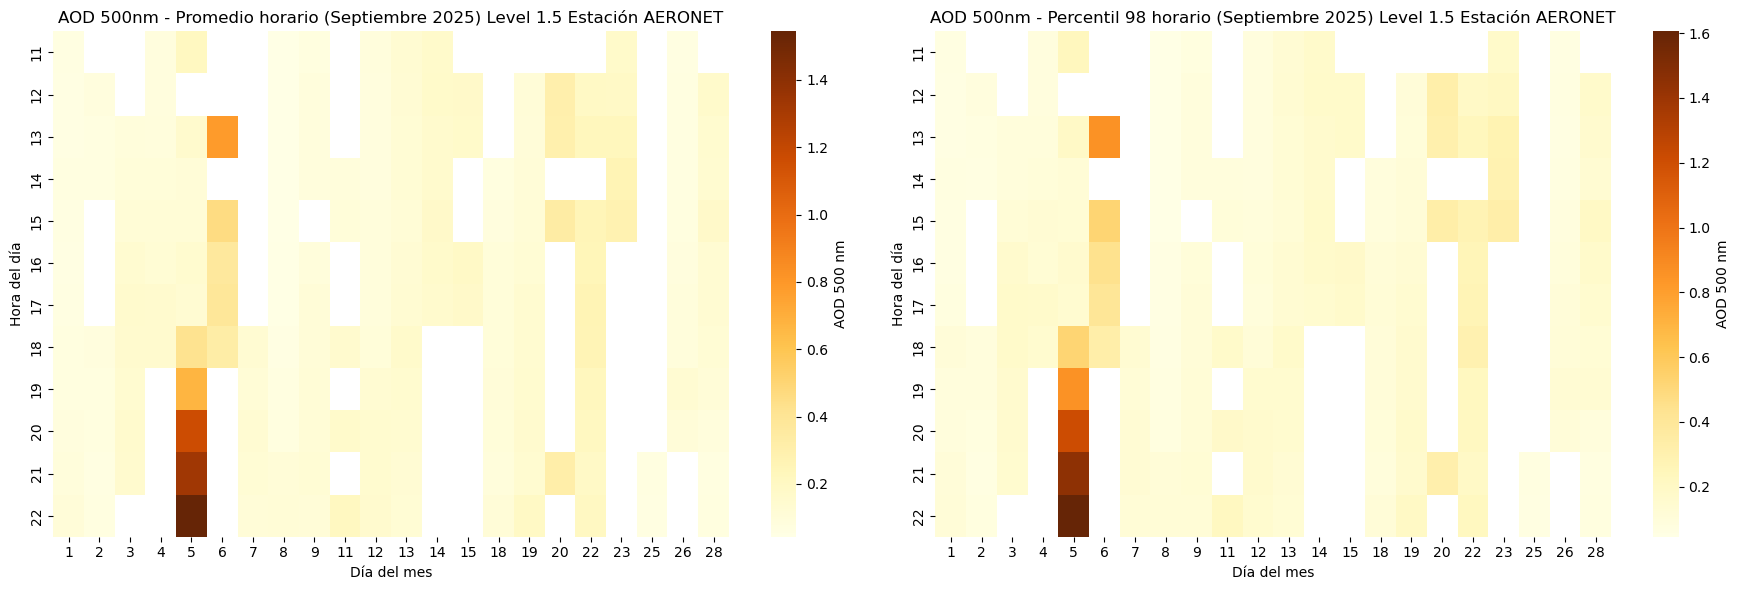

[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/AERONET/aeronet_202509_refstyle_L1_5.png


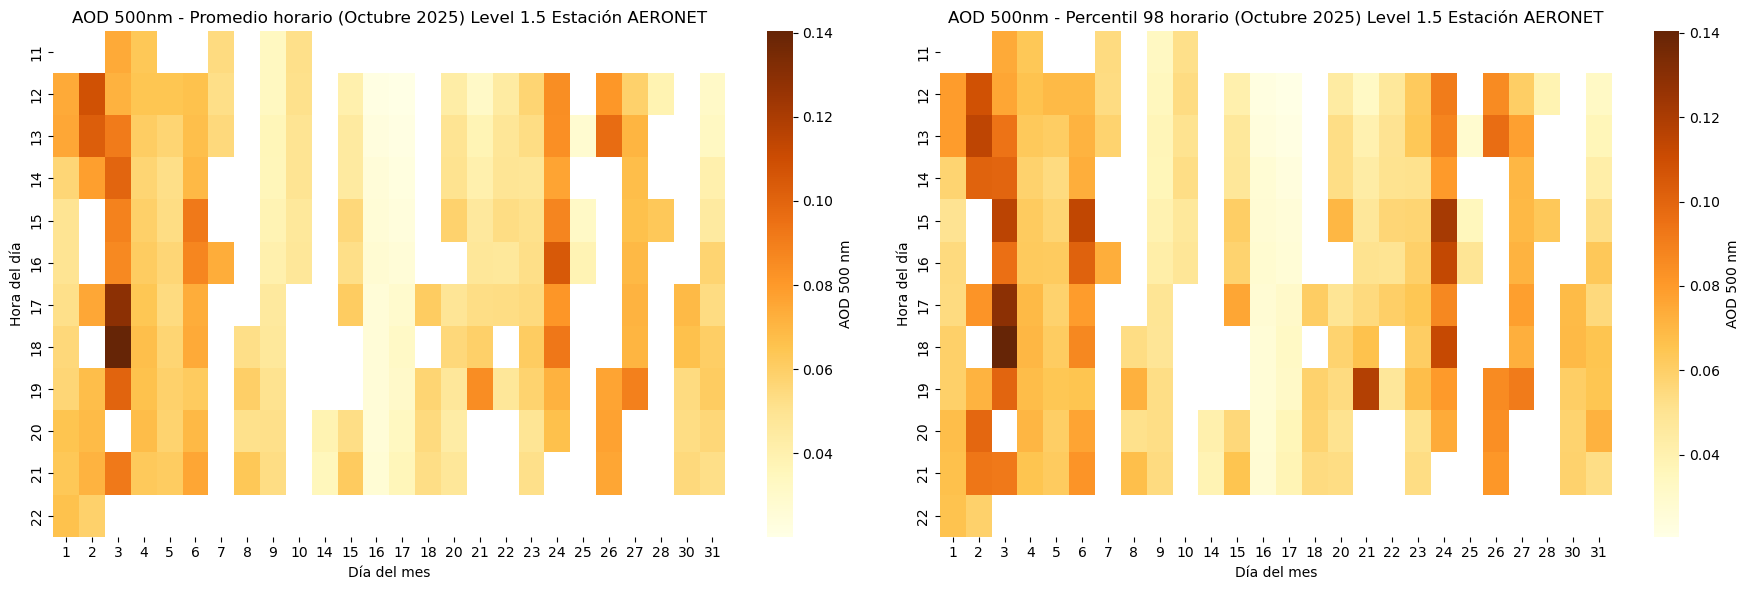

[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/AERONET/aeronet_202510_refstyle_L1_5.png


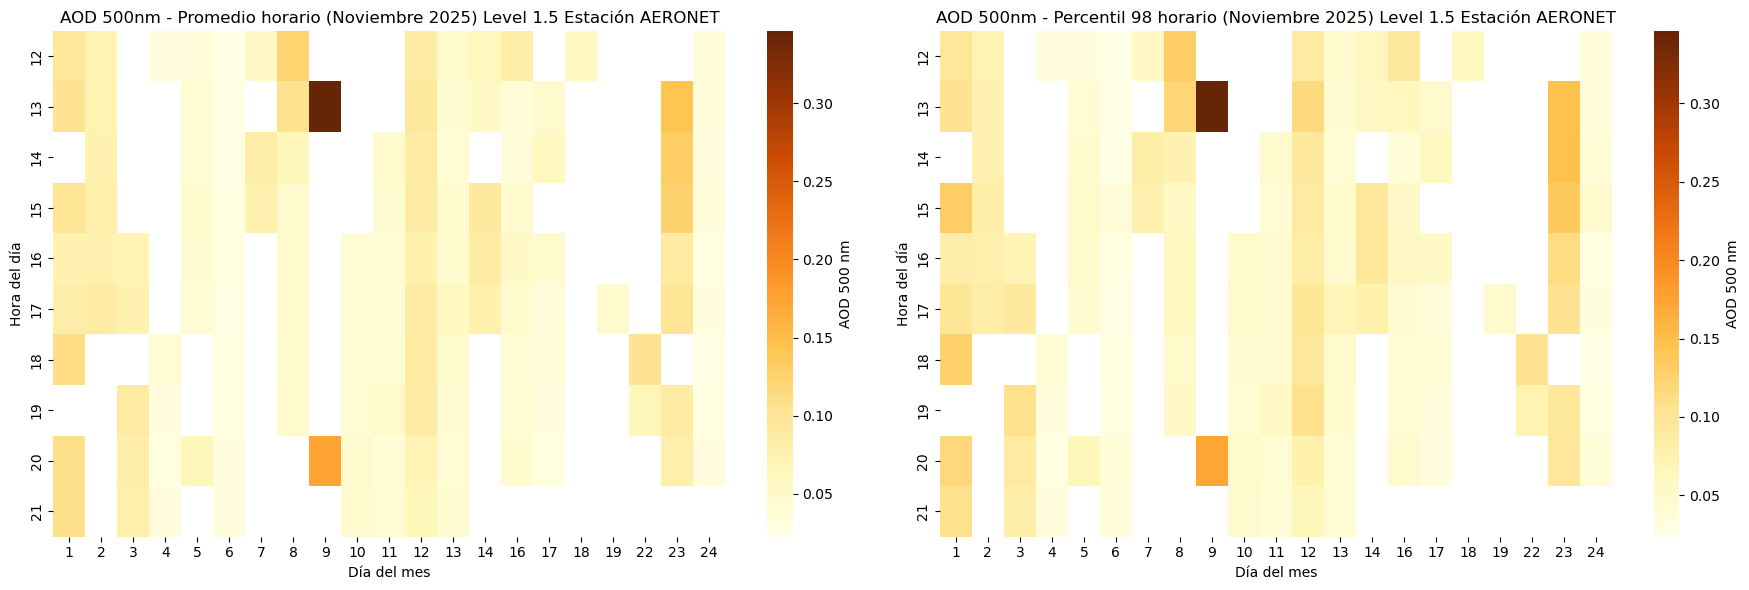

[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/AERONET/aeronet_202511_refstyle_L1_5.png
[AVISO] No hay datos para Diciembre 2025.


In [1]:
# ============================================
# AERONET 2025 — Estilo "referencia" (igual al código que pegaste)
# - Lee un .lev15 ANUAL
# - NO convierte zona horaria (se queda en UTC, como el original)
# - NO reindexa (sin huecos artificiales)
# - NO fija vmin/vmax (cada panel se autoescala, como el original)
# - Genera 1 PNG por mes, con los mismos argumentos de seaborn/matplotlib
# ============================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Config ----------
YEAR = 2025
LEV15_PATH = "/home/celesteurena/Asistencia_Gas-Lab/2025/AERONET/20250101_20251231_GSFC.lev15"
OUT_DIR = os.path.dirname(LEV15_PATH)

# (solo para títulos)
MESES_ES = ["", "Enero","Febrero","Marzo","Abril","Mayo","Junio",
            "Julio","Agosto","Septiembre","Octubre","Noviembre","Diciembre"]

# ---------- Lectura única (igual estilo de referencia) ----------
df = pd.read_csv(
    LEV15_PATH,
    skiprows=6,           # salta metadatos
    na_values='-999.000000'
)

# Datetime (igual que tu referencia, SIN conversión a LST)
df['datetime'] = pd.to_datetime(
    df['Date(dd:mm:yyyy)'] + ' ' + df['Time(hh:mm:ss)'],
    format='%d:%m:%Y %H:%M:%S',
    errors='coerce'
)

# Limpieza
df = df.dropna(subset=['datetime']).copy()

def plot_month_like_reference(year: int, month: int):
    # Filtrar solo ese mes/año en UTC (igual al script de referencia)
    dfm = df[(df['datetime'].dt.year == year) & (df['datetime'].dt.month == month)].copy()
    if dfm.empty:
        print(f"[AVISO] No hay datos para {MESES_ES[month]} {year}.")
        return

    # Extraer 'day' y 'hour' tal cual (en UTC)
    dfm['day']  = dfm['datetime'].dt.day
    dfm['hour'] = dfm['datetime'].dt.hour

    # Mantener variable de interés y limpiar
    aod_data = dfm[['day', 'hour', 'AOD_500nm']].dropna()
    if aod_data.empty:
        print(f"[AVISO] AOD_500nm vacío en {MESES_ES[month]} {year}.")
        return

    # === MISMAS OPERACIONES QUE TU SCRIPT DE REFERENCIA ===
    aod_mean = aod_data.groupby(['hour', 'day'])['AOD_500nm'].mean().unstack()
    aod_p98  = aod_data.groupby(['hour', 'day'])['AOD_500nm'].quantile(0.98).unstack()

    # Graficar con los mismos parámetros (cmap, cbar_kws, etc.)
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Promedio
    sns.heatmap(aod_mean, ax=axes[0], cmap='YlOrBr', cbar_kws={'label': 'AOD 500 nm'})
    axes[0].set_title(f'AOD 500nm - Promedio horario ({MESES_ES[month]} {year}) Level 1.5 Estación AERONET')
    axes[0].set_xlabel('Día del mes')
    axes[0].set_ylabel('Hora del día')

    # Percentil 98
    sns.heatmap(aod_p98, ax=axes[1], cmap='YlOrBr', cbar_kws={'label': 'AOD 500 nm'})
    axes[1].set_title(f'AOD 500nm - Percentil 98 horario ({MESES_ES[month]} {year}) Level 1.5 Estación AERONET')
    axes[1].set_xlabel('Día del mes')
    axes[1].set_ylabel('Hora del día')

    plt.tight_layout()
    plt.show()

    out_png = os.path.join(OUT_DIR, f"aeronet_{year}{month:02d}_refstyle_L1_5.png")
    fig.savefig(out_png, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"[OK] Guardado: {out_png}")

# ---------- Loop 12 meses ----------
for m in range(1, 13):
    plot_month_like_reference(YEAR, m)

# Datos Clarity: GasLab_SJ_CostaRica(DLHTB6526)

In [2]:
# ============================================
# Objetivo:
#   - Leer datos horarios de CLARITY (Año 2025 en un solo CSV)
#   - Para cada mes (1–12), calcular, por contaminante, matrices hora (0–23) x día (1–28/29/30/31)
#       * Percentil 98 por (hora, día)
#       * Promedio por (hora, día)
#   - Graficar ambos como mapas de calor (heatmaps) en una figura 2x3
#   - Guardar la figura como PNG en la MISMA carpeta del CSV
# ============================================

import pandas as pd              # Manejo de datos en tablas (DataFrame)
import matplotlib.pyplot as plt  # Gráficos base (figuras, ejes)
import seaborn as sns            # Gráficos estadísticos (heatmap, estilos)
from pathlib import Path         # Manejo robusto de rutas de archivos

# ----------- Carga y preparación de datos -----------

# df: DataFrame principal con todas las filas del CSV de 2025.
#     Se asume que el CSV tiene al menos las columnas:
#     'startOfPeriod', 'pm2_5ConcMass1HourMean.value',
#     'no2Conc1HourMean.value', 'o3Conc1HourMean.value'
p1 = Path("/home/celesteurena/Asistencia_Gas-Lab/2025/CLARITY/2025.csv")  # ✅ con guion_bajo
p2 = Path("/home/celesteurena/Asistencia-Gas-Lab/2025/CLARITY/2025.csv")  #    con guion

csv_path = p1 if p1.exists() else (p2 if p2.exists() else None)
if csv_path is None:
    raise FileNotFoundError(
        "No encuentro el CSV en ninguna de las dos rutas candidatas:\n"
        f"  - {p1}\n  - {p2}"
    )

df = pd.read_csv(csv_path)

# Convertimos la columna de tiempo a tipo datetime de pandas para poder extraer hora, día y mes fácilmente.
df['startOfPeriod'] = pd.to_datetime(df['startOfPeriod'])

# Creamos columnas auxiliares:
#   - 'hour': número de hora del día (0–23)
#   - 'day' : día del mes (1–31, según corresponda)
#   - 'month': número de mes (1–12)
df['hour']  = df['startOfPeriod'].dt.hour
df['day']   = df['startOfPeriod'].dt.day
df['month'] = df['startOfPeriod'].dt.month

# Directorio de salida = MISMA carpeta donde está el CSV
out_dir = csv_path.parent
out_dir.mkdir(parents=True, exist_ok=True)

# ----------- Diccionario de meses (para títulos) -----------

meses_es = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
    5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
    9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
}

# ----------- Diccionario de contaminantes -----------

# available_pollutants:
#   llave  -> etiqueta legible para el gráfico
#   valor  -> nombre exacto de la columna en el DataFrame
#   * Asegúrate que estas columnas existan en df
available_pollutants = {
    'PM2.5': 'pm2_5ConcMass1HourMean.value',
    'NO₂':   'no2Conc1HourMean.value',
    'O₃':    'o3Conc1HourMean.value'
}

# ----------- Bucle mensual (misma figura y cálculos por mes) -----------

for m in range(1, 13):
    # Filtrar el DataFrame al mes m
    df_m = df[df['month'] == m].copy()
    if df_m.empty:
        print(f"[OMITIDO] No hay datos para {meses_es[m]} 2025.")
        continue

    # ----------- Figura y ejes (subplots) -----------

    # Creamos una figura con 2 filas x 3 columnas de subplots:
    #   - Fila 1 (índices 0,1,2): percentil 98 por contaminante
    #   - Fila 2 (índices 3,4,5): promedio por contaminante
    # figsize en pulgadas (ancho=24, alto=12) para que se vea grande y legible
    fig, axes = plt.subplots(2, 3, figsize=(24, 12))

    # 'axes' llega como matriz 2x3; la aplanamos a vector de 6 ejes para indexar simple con i y i+3
    axes = axes.flatten()

    # ----------- Cálculos y gráficos por contaminante -----------

    # Recorremos el diccionario. enumerate(...) nos da:
    #   i       -> índice 0,1,2 (para colocar en la fila 1 y 2)
    #   label   -> texto corto para el título del plot (e.g., 'PM2.5')
    #   column  -> nombre de la columna en df (e.g., 'pm2_5ConcMass1HourMean.value')
    for i, (label, column) in enumerate(available_pollutants.items()):
        if column not in df_m.columns:
            print(f"[AVISO] Falta la columna '{column}' en {meses_es[m]} 2025. Se omite {label}.")
            axes[i].axis('off')
            axes[i + 3].axis('off')
            continue

        # ----- Calcular el percentil 98 por hora y día -----
        # Pasos:
        #   1) Seleccionamos solo las columnas necesarias: hour, day, y el contaminante 'column'
        #   2) dropna(): quitamos filas con NaN en cualquiera de esas columnas
        #   3) groupby(['hour','day']): agrupamos por par (hora, día)
        #   4) [column].quantile(0.98): percentil 98 dentro de cada grupo
        #   5) unstack(): pasa 'day' a columnas y 'hour' queda en el índice -> matriz hora x día
        data_percentil = (
            df_m[['hour', 'day', column]]
            .dropna()
            .groupby(['hour', 'day'])[column]
            .quantile(0.98)
            .unstack()
        )

        # ----- Calcular el promedio por hora y día -----
        # Idéntico flujo, pero usando .mean() en vez de .quantile(0.98)
        data_mean = (
            df_m[['hour', 'day', column]]
            .dropna()
            .groupby(['hour', 'day'])[column]
            .mean()
            .unstack()
        )

        # ----- Graficar heatmap del percentil 98 -----
        #   - ax=axes[i]        : ubicamos en la fila superior (índices 0,1,2)
        #   - cmap='RdYlGn_r'   : paleta invertida (rojo=alto, verde=bajo)
        #   - cbar_kws          : etiqueta de la barra de colores (unidades típicas µg/m³)
        sns.heatmap(data_percentil, ax=axes[i], cmap='RdYlGn_r', cbar_kws={'label': 'µg/m³'})
        axes[i].set_title(f'{label} - Percentil 98 horario ({meses_es[m]} 2025) Estación CLARITY')
        axes[i].set_xlabel('Día del mes')
        axes[i].set_ylabel('Hora del día')

        # ----- Graficar heatmap del promedio -----
        #   - ax=axes[i+3]      : ubicamos en la fila inferior (índices 3,4,5)
        sns.heatmap(data_mean, ax=axes[i + 3], cmap='RdYlGn_r', cbar_kws={'label': 'µg/m³'})
        axes[i + 3].set_title(f'{label} - Promedio horario ({meses_es[m]} 2025) Estación CLARITY')
        axes[i + 3].set_xlabel('Día del mes')
        axes[i + 3].set_ylabel('Hora del día')

    # ----------- Ajustes finales y exportación -----------

    # Ajusta automáticamente espacios para que títulos, ejes y colorbars no se encimen
    plt.tight_layout()

    # (Opcional) Mostrar en pantalla:
    # plt.show()

    # Guarda la figura en alta resolución (300 dpi) con bordes ajustados al contenido
    out_path = out_dir / f"clarity_{m:02d}_2025_heatmaps.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"[OK] Guardado: {out_path}")


[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/CLARITY/clarity_01_2025_heatmaps.png
[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/CLARITY/clarity_02_2025_heatmaps.png
[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/CLARITY/clarity_03_2025_heatmaps.png
[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/CLARITY/clarity_04_2025_heatmaps.png
[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/CLARITY/clarity_05_2025_heatmaps.png
[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/CLARITY/clarity_06_2025_heatmaps.png
[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/CLARITY/clarity_07_2025_heatmaps.png
[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/CLARITY/clarity_08_2025_heatmaps.png
[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/CLARITY/clarity_09_2025_heatmaps.png
[OK] Guardado: /home/celesteurena/Asistencia_Gas-Lab/2025/CLARITY/clarity_10_2025_heatmaps.png
[OK] Guardado: /home/celesteurena/Asistencia_Gas-L

# IMN

In [21]:
# ============================================
# IMN — Heatmaps hora×día por MES (dos salidas por mes)
#   1) imn_YYYYMM_main_heatmaps.png  -> O₃, NO₂, PM2.5
#   2) imn_YYYYMM_SO2_heatmaps.png   -> SO₂ (solo)
#   - Carpeta CSV: /home/celesteurena/Asistencia_Gas-Lab/2025/IMN/
#   - Columnas esperadas: dt, PM1, PM2.5, PM10, NO₂/SO₂/O₃ (o NO2/SO2/O3)
# ============================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 1) Configuración
# ==============================
BASE_DIR   = Path("/home/celesteurena/Asistencia_Gas-Lab/2025/IMN/")
FNAME_GLOB = "clean_*_2025??.csv"  # p.ej. clean_1653_202501.csv

MESES_ES = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
    5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
    9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
}

UNITS = {
    "PM2.5": "µg/m³",
    "NO₂": "ppb", "O₃": "ppb", "SO₂": "ppb",
    # fallbacks si vienen sin subíndice:
    "NO2": "ppb", "O3": "ppb", "SO2": "ppb"
}

# Orden requerido para el gráfico principal
MAIN_ORDER = ["PM2.5", "NO₂","O₃"]  # exactamente en este orden
# ==============================
# 2) Funciones auxiliares
# ==============================
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Homogeneiza nombres: NO2->NO₂, SO2->SO₂, O3->O₃. Conserva PM2.5.
    """
    ren = {
        "NO2": "NO₂", "NO_2": "NO₂", "NO^2": "NO₂",
        "SO2": "SO₂", "SO_2": "SO₂", "SO^2": "SO₂",
        "O3": "O₃",   "O_3": "O₃",   "O^3": "O₃",
        "PM25": "PM2.5", "PM2_5": "PM2.5"
    }
    out = df.copy()
    out.columns = [ren.get(c, c) for c in out.columns]
    return out

def ensure_datetime(df: pd.DataFrame) -> pd.DataFrame:
    """Convierte 'dt' a datetime y crea hour/day/month."""
    if "dt" not in df.columns:
        raise ValueError("No se encontró la columna temporal 'dt'.")
    out = df.copy()
    out["__dt__"] = pd.to_datetime(out["dt"], errors="coerce")
    out = out.dropna(subset=["__dt__"])
    out["hour"]  = out["__dt__"].dt.hour
    out["day"]   = out["__dt__"].dt.day
    out["month"] = out["__dt__"].dt.month
    return out

def compute_matrices(df_m: pd.DataFrame, col: str):
    """Devuelve (p98, mean) como DataFrames hora×día, con días continuos."""
    base = df_m[["hour", "day", col]].dropna()
    if base.empty:
        return None, None
    p98  = base.groupby(["hour", "day"])[col].quantile(0.98).unstack()
    mean = base.groupby(["hour", "day"])[col].mean().unstack()
    # Orden y reindex por días continuos
    p98  = p98.sort_index().sort_index(axis=1)
    mean = mean.sort_index().sort_index(axis=1)
    days = list(range(int(base["day"].min()), int(base["day"].max()) + 1))
    p98  = p98.reindex(columns=days)
    mean = mean.reindex(columns=days)
    return p98, mean

def ym_from_stem(stem: str, fallback_month: int) -> str:
    """Extrae YYYYMM del nombre del archivo, o construye 2025MM."""
    for token in stem.split("_"):
        if token.isdigit() and len(token) in (6, 8):  # 202501 o 20250101
            return token[:6]
    return f"2025{int(fallback_month):02d}"

def plot_panel(ax, data, title, unit):
    sns.heatmap(data, ax=ax, cmap="RdYlGn_r", cbar_kws={"label": unit})
    ax.set_title(title)
    ax.set_xlabel("Día del mes")
    ax.set_ylabel("Hora del día")
    ax.invert_yaxis()  # 0 h abajo

# ==============================
# 3) Procesamiento — genera dos salidas por mes
# ==============================
files = sorted(BASE_DIR.glob(FNAME_GLOB))
if not files:
    raise FileNotFoundError(f"No se encontraron archivos en {BASE_DIR} con patrón {FNAME_GLOB}")

for f in files:
    try:
        df = pd.read_csv(f)
    except Exception as e:
        print(f"[OMITIDO] {f.name}: no se pudo leer ({e})")
        continue

    df = normalize_columns(df)

    try:
        df = ensure_datetime(df)
    except Exception as e:
        print(f"[OMITIDO] {f.name}: {e}")
        continue

    if df.empty:
        print(f"[OMITIDO] {f.name}: sin filas válidas tras parseo de tiempo.")
        continue

    for m in sorted(df["month"].unique()):
        df_m = df[df["month"] == m]
        if df_m.empty:
            continue

        mes_txt = MESES_ES.get(m, m)
        ym = ym_from_stem(f.stem, m)

        # ========= FIGURA 1: MAIN (O₃, NO₂, PM2.5) =========
        main_labels = [lab for lab in MAIN_ORDER if lab in df_m.columns]
        if main_labels:
            ncols = len(main_labels)
            fig_main, axes_main = plt.subplots(2, ncols, figsize=(8*ncols, 12))
            if ncols == 1:
                axes_main = [[axes_main[0]], [axes_main[1]]]

            for j, col in enumerate(main_labels):
                p98, mean = compute_matrices(df_m, col)
                if p98 is None:
                    # apagar ambos paneles si no hay datos
                    (axes_main[0][j] if ncols == 1 else axes_main[0, j]).axis("off")
                    (axes_main[1][j] if ncols == 1 else axes_main[1, j]).axis("off")
                    print(f"[AVISO] {f.name}: {col} sin datos suficientes.")
                    continue

                unit = UNITS.get(col, "unid.")
                ax_top = axes_main[0][0] if ncols == 1 else axes_main[0, j]
                ax_bot = axes_main[1][0] if ncols == 1 else axes_main[1, j]

                plot_panel(ax_top, p98,  f"{col} — P98 horario ({mes_txt} 2025)", unit)
                plot_panel(ax_bot, mean, f"{col} — Promedio horario ({mes_txt} 2025)", unit)

            plt.tight_layout()
            out_main = f.parent / f"imn_{ym}_main_heatmaps.png"
            plt.savefig(out_main, dpi=300, bbox_inches="tight")
            plt.close()
            print(f"[OK] Guardado MAIN: {out_main}")
        else:
            print(f"[AVISO] {f.name} ({mes_txt}): no hay ninguna de {MAIN_ORDER}.")

        # ========= FIGURA 2: SOLO SO₂ =========
        so2_col = "SO₂" if "SO₂" in df_m.columns else ("SO2" if "SO2" in df_m.columns else None)
        if so2_col is None:
            print(f"[AVISO] {f.name} ({mes_txt}): no hay columna SO₂/SO2.")
            continue

        p98_s, mean_s = compute_matrices(df_m, so2_col)
        if p98_s is None:
            print(f"[AVISO] {f.name}: {so2_col} sin datos suficientes.")
            continue

        fig_so2, axes_so2 = plt.subplots(2, 1, figsize=(10, 12))
        plot_panel(axes_so2[0], p98_s,  f"{so2_col} — P98 horario ({mes_txt} 2025 Estación CIGEFI)", UNITS.get(so2_col, "ppb"))
        plot_panel(axes_so2[1], mean_s, f"{so2_col} — Promedio horario ({mes_txt} 2025 Estación CIGEFI)", UNITS.get(so2_col, "ppb"))
        plt.tight_layout()
        out_so2 = f.parent / f"imn_{ym}_SO2_heatmaps.png"
        plt.savefig(out_so2, dpi=300, bbox_inches="tight")
        plt.close()
        print(f"[OK] Guardado SO2: {out_so2}")


[OK] Guardado MAIN: /home/celesteurena/Asistencia_Gas-Lab/2025/IMN/imn_202501_main_heatmaps.png
[OK] Guardado SO2: /home/celesteurena/Asistencia_Gas-Lab/2025/IMN/imn_202501_SO2_heatmaps.png
[OK] Guardado MAIN: /home/celesteurena/Asistencia_Gas-Lab/2025/IMN/imn_202502_main_heatmaps.png
[OK] Guardado SO2: /home/celesteurena/Asistencia_Gas-Lab/2025/IMN/imn_202502_SO2_heatmaps.png
[OK] Guardado MAIN: /home/celesteurena/Asistencia_Gas-Lab/2025/IMN/imn_202502_main_heatmaps.png
[OK] Guardado SO2: /home/celesteurena/Asistencia_Gas-Lab/2025/IMN/imn_202502_SO2_heatmaps.png
[OK] Guardado MAIN: /home/celesteurena/Asistencia_Gas-Lab/2025/IMN/imn_202503_main_heatmaps.png
[OK] Guardado SO2: /home/celesteurena/Asistencia_Gas-Lab/2025/IMN/imn_202503_SO2_heatmaps.png
[OK] Guardado MAIN: /home/celesteurena/Asistencia_Gas-Lab/2025/IMN/imn_202503_main_heatmaps.png
[OK] Guardado SO2: /home/celesteurena/Asistencia_Gas-Lab/2025/IMN/imn_202503_SO2_heatmaps.png
[OK] Guardado MAIN: /home/celesteurena/Asistencia_